pystran - Python package for structural analysis with trusses and beams

(C) 2025, Petr Krysl, pkrysl@ucsd.edu

# Weaver 3D frame benchmark

Last updated: 07/11/26

## Problem description

This example is a 3D frame for which multiple independent solutions are
available in the open literature (hence, it is a benchmark).

Displacements, reactions, and internal forces are provided in the verification
manual.

A number of quantities can be checked against independent solutions. 

These reactions are consistent with STAAD.Pro 2023.00.03 User Manual, assuming
Poisson ratio 0.25:
```
Joint 3:
   Rx=-1.1041, Ry=-0.43222, Rz=0.21731, Mx=48.785, My=-17.973, Mz=96.122:
Joint 4:
   Rx=-0.89588, Ry=1.4322, Rz=-0.21731, Mx=123.08, My=47.246, Mz=-11.72:
```
The internal forces can also be checked against the manual (but the number of
available digits in the manual is limited).

## References

The original source is Weaver Jr., W., Computer Programs for Structural
Analysis, page 146, problem 8.

It is accessible online via the STAAD.Pro 2023.00.03 User Manual.


## Documentation

[pystran docs](https://petrkryslucsd.github.io/pystran)

We begin with the standard imports:

In [132]:
from numpy import array
from numpy.linalg import norm
import context
from pystran import model
from pystran import section
from pystran import plots
from pystran import rotation
from pystran import beam

from pystran import plots
from pystran import beam
from pystran import rotation

Define a few constants:
US customary units, inches, pounds, seconds are assumed.


In [133]:
L = 120.0
E = 30000
nu = 0.25  # Poisson's ratio assumed in STAAD documentation
G = E / (2 * (1 + nu))
A = 11
Iz = 56
Iy = 56
Ix = 83
J = Ix  # Torsional constant
F = 2
P = 1
M = 120

The model is created as three dimensional (3 as argument!).


In [134]:
m = model.create(3)
freedoms = m["freedoms"]

Joints are added at their locations, and the supports of the clamped joints
are specified.


In [135]:
model.add_joint(m, 3, [0.0, 0.0, 0.0])
model.add_joint(m, 1, [0.0, L, 0.0])
model.add_joint(m, 2, [2 * L, L, 0.0])
model.add_joint(m, 4, [3 * L, 0.0, L])

{'jid': 4, 'coordinates': array([360.,   0., 120.])}

All degrees of freedom suppressed -- fixed (clamped) condition.

In [136]:
model.add_support(m["joints"][3], freedoms.ALL_DOFS)
model.add_support(m["joints"][4], freedoms.ALL_DOFS)

At this point we can visualize the supports. The translation supports are
shown with arrow heads.


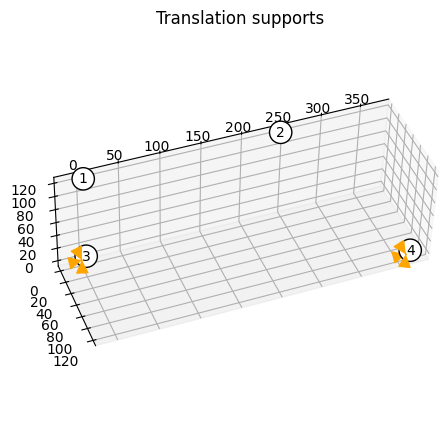

In [137]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_translation_supports(m)
ax.view_init(elev=137, azim=-67, roll=30)
ax.set_title("Translation supports")
plots.show(m)

The rotation supports are shown next.


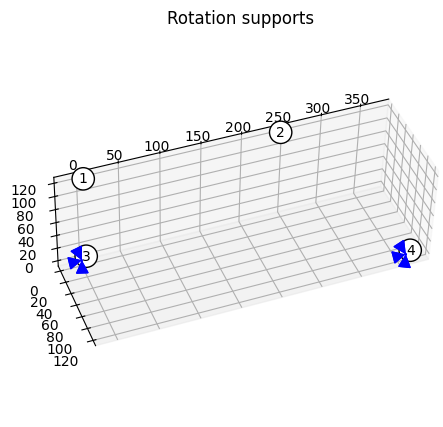

In [138]:
ax = plots.setup(m)
plots.plot_joint_ids(m)
plots.plot_rotation_supports(m)
ax.view_init(elev=137, azim=-67, roll=30)
ax.set_title("Rotation supports")
plots.show(m)

There are three beams. The cross sectional properties are the same, but they
have different orientation of their local coordinate systems in space.
Therefore, we create two sections. The first section orients the beam local
coordinate system such that the x-z planes contains the vector [0, 0, 1].

In [139]:
xz_vector = [0, 0, 1]
sect_1 = section.beam_3d_section(
    "sect_1", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

The second section is for the inclined beam, whose local coordinate system
needs to be oriented so that one of the axes is parallel to the global plane
`X-Z`. We accomplish that here by rotating the vector `[0, 1, 0]` by ninety
degrees about the axis of the beam.

In [140]:
xz_vector = rotation.rotate(m["joints"][2], m["joints"][4], [0, 1, 0], 90)
sect_2 = section.beam_3d_section(
    "sect_3", E=E, G=G, A=A, Ix=Ix, Iy=Iy, Iz=Iz, J=J, xz_vector=xz_vector
)

With the above definitions of the sections at hand, we define the three
members.

In [141]:
model.add_beam_member(m, 1, [1, 2], sect_1)
model.add_beam_member(m, 2, [3, 1], sect_1)
model.add_beam_member(m, 3, [2, 4], sect_2)

{'mid': 3,
 'connectivity': [2, 4],
 'section': {'name': 'sect_3',
  'E': 30000,
  'G': 12000.0,
  'rho': 0.0,
  'CTE': 0.0,
  'A': 11,
  'Ix': 83,
  'Iy': 56,
  'Iz': 56,
  'J': 83,
  'xy_vector': None,
  'xz_vector': array([-0.9106836 ,  0.33333333,  0.24401694])}}

Now we can plot the geometry of the structure. We show the members, the
member numbers, and the ids of the joints.

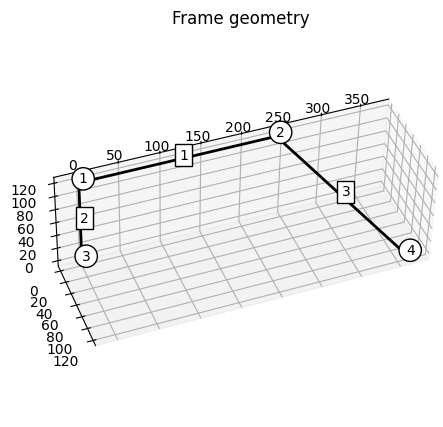

In [142]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_ids(m)
plots.plot_joint_ids(m)
ax.view_init(elev=137, azim=-67, roll=30)
ax.set_title("Frame geometry")
plots.show(m)

We can also show the local coordinate systems for each member (member x is red, y is green, z is blue -- rgb).

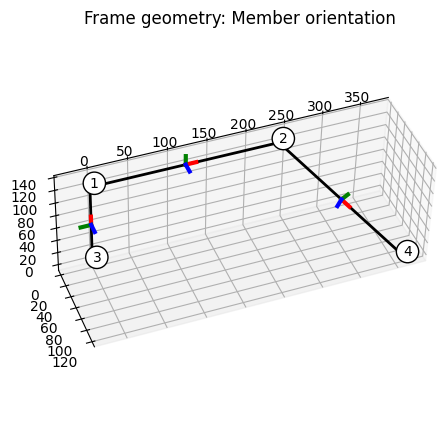

In [143]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_joint_ids(m)
plots.plot_member_orientation(m)
ax.view_init(elev=137, azim=-67, roll=30)
ax.set_title("Frame geometry: Member orientation")
plots.show(m)

Next we add the forces and moments applied at the joints.

In [144]:
model.add_load(m["joints"][1], freedoms.U1, F)
model.add_load(m["joints"][2], freedoms.U2, -P)
model.add_load(m["joints"][2], freedoms.UR3, -M)

And the applied forces can now be rendered.

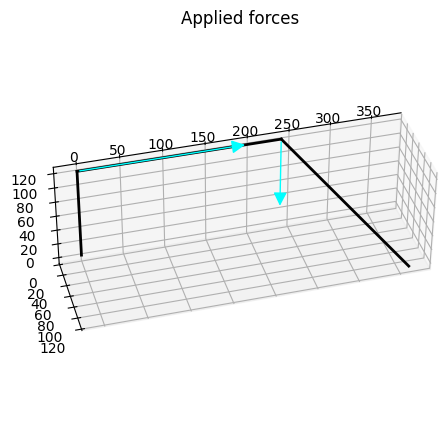

In [145]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_applied_forces(m, 100.0)
ax.view_init(elev=130, azim=-70, roll=25)
ax.set_title("Applied forces")
plots.show(m)

Similarly, we can render the applied moments:

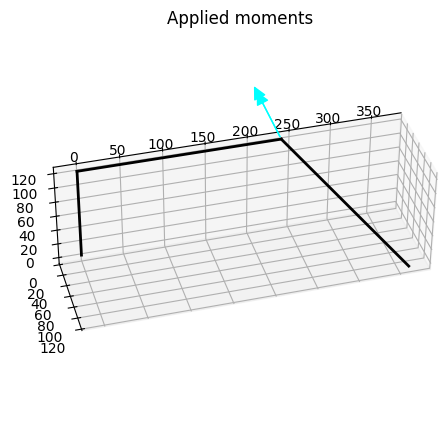

In [146]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_applied_moments(m, 1.0)
ax.view_init(elev=130, azim=-70, roll=25)
ax.set_title("Applied moments")
plots.show(m)

Now we can solve the static equilibrium of the frame. First we number the
degrees of freedom, and then we call the solver that will construct the
stiffness matrix, the right-hand side vector of applied generalized forces
(forces plus moments), and solve a system of equations. The solution is then
distributed to the joints.


In [147]:
model.number_dofs(m)
model.solve_statics(m)

The displacements of the joints can be printed out. Recall that joints 3 and
4 are clamped, and their displacements are therefore zero.


In [148]:
for jid in [1, 2]:
    j = m["joints"][jid]
    print(jid, j["displacements"])

1 [ 2.22671486e-01  1.57169864e-04 -1.71823075e-01 -2.55327295e-03
  2.16542311e-03 -2.13387464e-03]
2 [ 0.22201994 -0.48118948 -0.70160623 -0.00802487  0.00100766 -0.00434716]


The displacements of the joints can be compared to the reference values.
These are the displacements of joint 1:


In [149]:
ref1 = [0.22267, 0.00016, -0.17182, -0.00255, 0.00217, -0.00213]
if norm(m["joints"][1]["displacements"] - ref1) > 1.0e-1 * norm(ref1):
    raise ValueError("Displacement calculation error")
print("Displacement calculation OK")
# These are the displacements of joint 2:
ref2 = [0.22202, -0.48119, -0.70161, -0.00802, 0.00101, -0.00435]
if norm(m["joints"][2]["displacements"] - ref2) > 1.0e-1 * norm(ref2):
    raise ValueError("Displacement calculation error")
print("Displacement calculation OK")

Displacement calculation OK
Displacement calculation OK


The internal forces in the members can be calculated. Here we report the
"end forces", i.e., the forces and moments at the ends of the members that
act on the joints.


In [150]:
for k in m["beam_members"].keys():
    member = m["beam_members"][k]
    connectivity = member["connectivity"]
    i, j = m["joints"][connectivity[0]], m["joints"][connectivity[1]]
    f = beam.beam_3d_end_forces(member, i, j)
    print(f"Member {k}: ")
    print(f"   Joint {connectivity[0]}: ")
    print(f"   N={f['Ni']:.5}, Qy={f['Qyi']:.5}, Qz={f['Qzi']:.5}")
    print(f"   T={f['Ti']:.5}, My={f['Myi']:.5}, Mz={f['Mzi']:.5}")
    print(f"   Joint {connectivity[1]}: ")
    print(f"   N={f['Nj']:.5}, Qy={f['Qyj']:.5}, Qz={f['Qzj']:.5}")
    print(f"   T={f['Tj']:.5}, My={f['Myj']:.5}, Mz={f['Mzj']:.5}")

Member 1: 
   Joint 1: 
   N=-0.89588, Qy=0.43222, Qz=-0.21731
   T=-22.707, My=17.973, Mz=36.373
   Joint 2: 
   N=0.89588, Qy=-0.43222, Qz=0.21731
   T=22.707, My=34.182, Mz=67.359
Member 2: 
   Joint 3: 
   N=0.43222, Qy=-1.1041, Qz=-0.21731
   T=17.973, My=48.785, Mz=-96.122
   Joint 1: 
   N=-0.43222, Qy=1.1041, Qz=0.21731
   T=-17.973, My=-22.707, Mz=-36.373
Member 3: 
   Joint 2: 
   N=-1.4696, Qy=0.71494, Qz=0.47982
   T=37.017, My=-15.689, Mz=53.279
   Joint 4: 
   N=1.4696, Qy=-0.71494, Qz=-0.47982
   T=-37.017, My=-84.04, Mz=95.319


The reactions at the supports can be calculated. The reactions at joints 3
and 4 are compared to the reference values.


In [151]:
model.statics_reactions(m)

In [152]:
for jid in [3, 4]:
    j = m["joints"][jid]
    print(f"Joint {jid}:")
    print(f"   Rx={j['reactions'][0]:.5}")
    print(f"   Ry={j['reactions'][1]:.5}")
    print(f"   Rz={j['reactions'][2]:.5}")
    print(f"   Mx={j['reactions'][3]:.5}")
    print(f"   My={j['reactions'][4]:.5}")
    print(f"   Mz={j['reactions'][5]:.5}")

Joint 3:
   Rx=-1.1041
   Ry=-0.43222
   Rz=0.21731
   Mx=48.785
   My=-17.973
   Mz=96.122
Joint 4:
   Rx=-0.89588
   Ry=1.4322
   Rz=-0.21731
   Mx=123.08
   My=47.246
   Mz=-11.72


In [153]:
# For joint 3:
j = m["joints"][3]
react3 = array(
    [
        j["reactions"][0],
        j["reactions"][1],
        j["reactions"][2],
        j["reactions"][3],
        j["reactions"][4],
        j["reactions"][5],
    ]
)
ref = array([-1.1041, -0.43222, 0.21731, 48.785, -17.973, 96.122])
if norm((react3 - ref) / ref) > 1e-3:
    raise ValueError("Reaction error")
print("Reaction calculation OK")

Reaction calculation OK


The frame can be considered, with the supports removed and replaced by
reactions, a free body. Therefore we can formulate a condition that all
forces and all moments need to add up to zero. The function below calculates
those resultants:

In [154]:
allforces = model.free_body_check(m)
print("Sum of forces and moments: ", allforces)
if norm(allforces) > 1.0e-10:
    raise ValueError("Sum of forces and moments not zero")

Sum of forces and moments:  [ 0.00000000e+00  0.00000000e+00  0.00000000e+00  7.73070497e-12
  2.92743607e-11 -1.52340363e-11]


We can see that the overall balance as a free body is satisfied.

The solution to the problem can be visualized with a number of plots. We
start with the deformed shape of the frame.


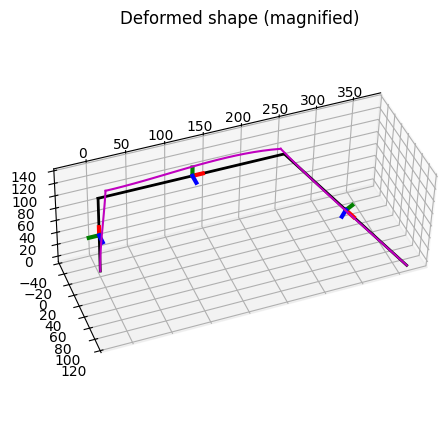

In [155]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m)
ax = plots.plot_deformations(m)
ax.set_title("Deformed shape (magnified)")
ax.view_init(elev=137, azim=-67, roll=30)
plots.show(m)

The shear forces in the members can be visualized with diagrams.
For instance, the shear forces along the z-axis are shown.


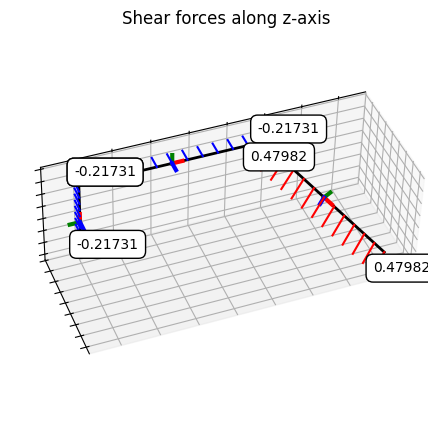

In [156]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m)
ax = plots.plot_shear_forces(m)
ax.set_title("Shear forces along z-axis")
ax.view_init(elev=137, azim=-67, roll=30)
plots.show(m)

Analogous diagrams can be produced for the torsional moments in the members.


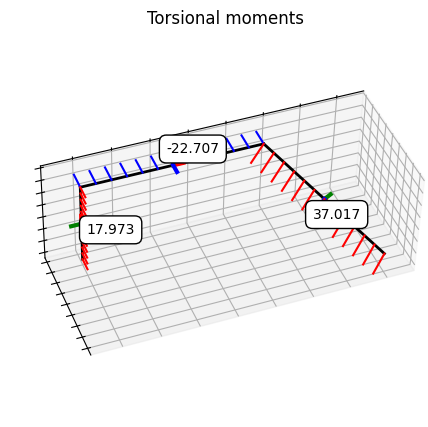

In [157]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m)
ax = plots.plot_torsion_moments(m)
ax.set_title("Torsional moments")
ax.view_init(elev=137, azim=-67, roll=30)
plots.show(m)

Finally, the axial forces in the members can be visualized.


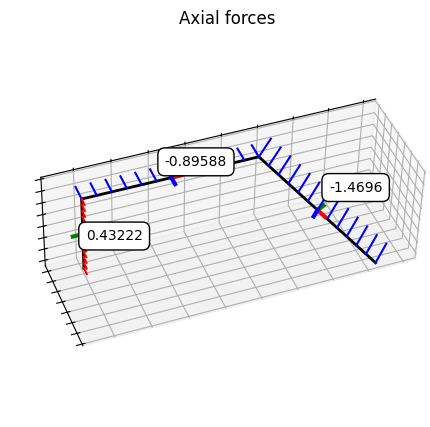

In [158]:
ax = plots.setup(m)
plots.plot_members(m)
plots.plot_member_orientation(m)
ax = plots.plot_axial_forces(m)
ax.set_title("Axial forces")
ax.view_init(elev=137, azim=-67, roll=30)
plots.show(m)

We have computed the reactions above. Now we can visualize them.


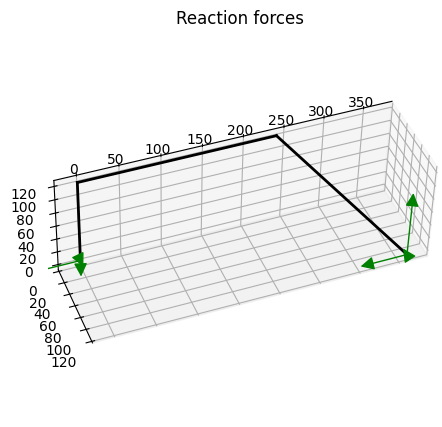

In [159]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_reaction_forces(m)
ax.set_title("Reaction forces")
ax.view_init(elev=137, azim=-67, roll=30)
plots.show(m)

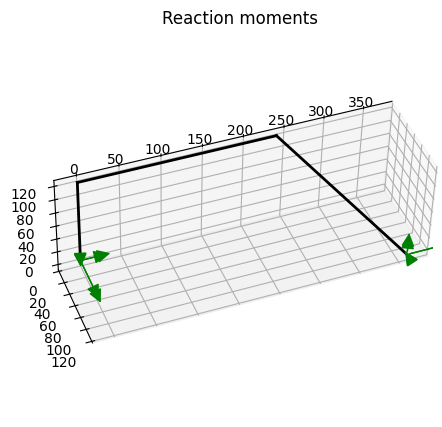

In [160]:
ax = plots.setup(m)
plots.plot_members(m)
ax = plots.plot_reaction_moments(m)
ax.set_title("Reaction moments")
ax.view_init(elev=137, azim=-67, roll=30)
plots.show(m)